In [1]:
# Bibliotecas
import pvlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pvlib.location import Location


In [2]:
#Importando dados de Estação Meteorológica 
#Localização da Universidade de Oregon
latitude = 44.0446
longitude = -123.0726
altitude = 123.0
site = pvlib.location.Location(latitude, longitude)


df_weather = pvlib.iotools.read_midc_raw_data_from_nrel('UOSMRL',               # Station id
                                                    pd.Timestamp('20210101'),   # Start date YYYYMMDD
                                                    pd.Timestamp('20211231'))   # End date  YYYYMMDD

df_weather.head(3)

,Unnamed: 0,Year,DOY,PST,SR20 Temp [deg C],Direct NIP [W/m^2],Diffuse [W/m^2],Global LI-200 [W/m^2],Relative Humidity [%],Air Temperature [deg C],...,CHP1 Temp [deg K],CMP22 Temp [deg K],Avg Wind Direction @ 10m [deg from N],Zenith Angle [degrees],Azimuth Angle [degrees],Airmass,Solar Eclipse Shading,Direct SAMPA/Bird (calc) [W/m^2],Global SAMPA/Bird (calc) [W/m^2],Diffuse SAMPA/Bird (calc) [W/m^2]
2021-01-01 00:00:00-08:00,0,2021,1,0,-0.002,0.000,-1.057,0.017,80.8,9.05,...,282.0,283.2,131.4,158.67385,349.90342,-1.0,0.0,0.0,0.0,0.0
2021-01-01 00:01:00-08:00,0,2021,1,1,0.002,0.123,-1.039,0.030,80.6,9.09,...,281.9,283.2,149.0,158.70431,350.53096,-1.0,0.0,0.0,0.0,0.0
2021-01-01 00:02:00-08:00,0,2021,1,2,0.005,0.181,-1.041,0.028,80.3,9.10,...,281.9,283.2,150.8,158.73283,351.16003,-1.0,0.0,0.0,0.0,0.0


In [3]:
df_weather = df_weather[['Global CMP22 [W/m^2]', 'Diffuse [W/m^2]','Direct CHP1 [W/m^2]']]
# Rename the columns
df_weather.columns = ['ghi', 'dhi', 'dni']

In [4]:
df = df_weather.resample('1H').mean() # df é a variável definida para ser usada na avaliação do recurso solar nos conjuntos de códigos mais adiante.

'''
Se quiser juntar dataframes diferentes, pode usar essa função:
df = pd.DataFrame({'GHI': satelite['ghi'],
                   'DHI': modelo_de_decomposição['dhi'],
                   'DNI': modelo_de_decomposição['dni'],})

Assim, incorpora dados de GHI, DNI e DHI de diferentes fontes em um único dataframe, já identificando o nome para cada coluna.

Outra forma de atribuir diferentes dataframes a um único dataframe é:

df = pd.concat([nsrdb_data_2020, nsrdb_data_2021, nsrdb_data_2022])

Dessa forma é possível juntar três anos de dados seguidos em um único dataframe.
'''

C:\Users\joaof\AppData\Local\Temp\ipykernel_13404\467161207.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df_weather.resample('1H').mean() # df é a variável definida para ser usada na avaliação do recurso solar nos conjuntos de códigos mais adiante.


"\nSe quiser juntar dataframes diferentes, pode usar essa função:\ndf = pd.DataFrame({'GHI': satelite['ghi'],\n                   'DHI': modelo_de_decomposição['dhi'],\n                   'DNI': modelo_de_decomposição['dni'],})\n\nAssim, incorpora dados de GHI, DNI e DHI de diferentes fontes em um único dataframe, já identificando o nome para cada coluna.\n\nOutra forma de atribuir diferentes dataframes a um único dataframe é:\n\ndf = pd.concat([nsrdb_data_2020, nsrdb_data_2021, nsrdb_data_2022])\n\nDessa forma é possível juntar três anos de dados seguidos em um único dataframe.\n"

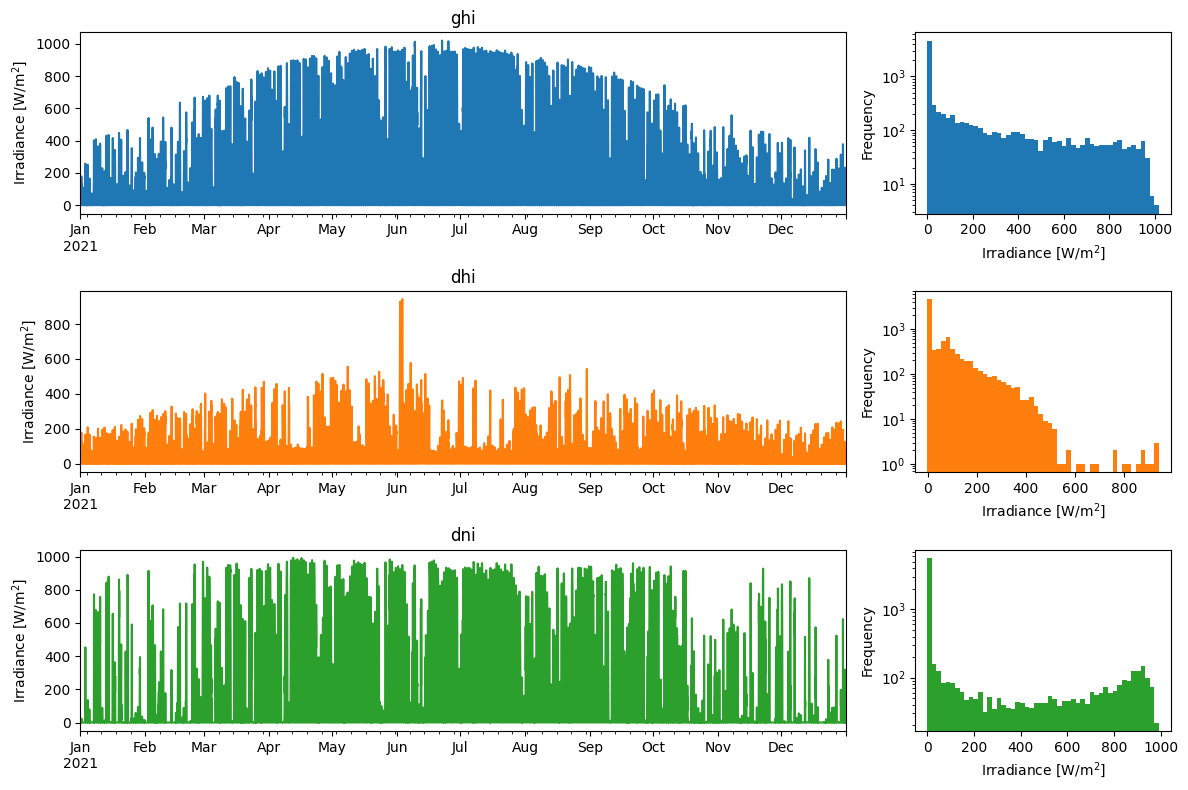

In [5]:
#Fazer essa análise com Dados Horários!

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12,8), gridspec_kw={'width_ratios':[3,1]})
for i, c in enumerate(['ghi','dhi','dni']):
    df[c].plot(ax=axes[i,0], c='C{}'.format(i), title=c)
    df[c].plot.hist(ax=axes[i,1], logy=True, bins=50, facecolor='C{}'.format(i))
    axes[i,0].set_xlabel('')
    axes[i,0].set_ylabel('Irradiance [W/m$^2$]')
    axes[i,1].set_xlabel('Irradiance [W/m$^2$]')
fig.tight_layout()

In [6]:
days = pd.date_range(df.index[0], df.index[-1]) # List of days for which to calculate sunrise/sunset

sunrise_sunset = pvlib.solarposition.sun_rise_set_transit_spa(days, latitude=latitude, longitude=longitude)

# Convert sunrise/sunset from Datetime to hours (decimal)
sunrise_sunset['sunrise'] = sunrise_sunset['sunrise'].dt.hour + sunrise_sunset['sunrise'].dt.minute/60
sunrise_sunset['sunset'] = sunrise_sunset['sunset'].dt.hour + sunrise_sunset['sunset'].dt.minute/60

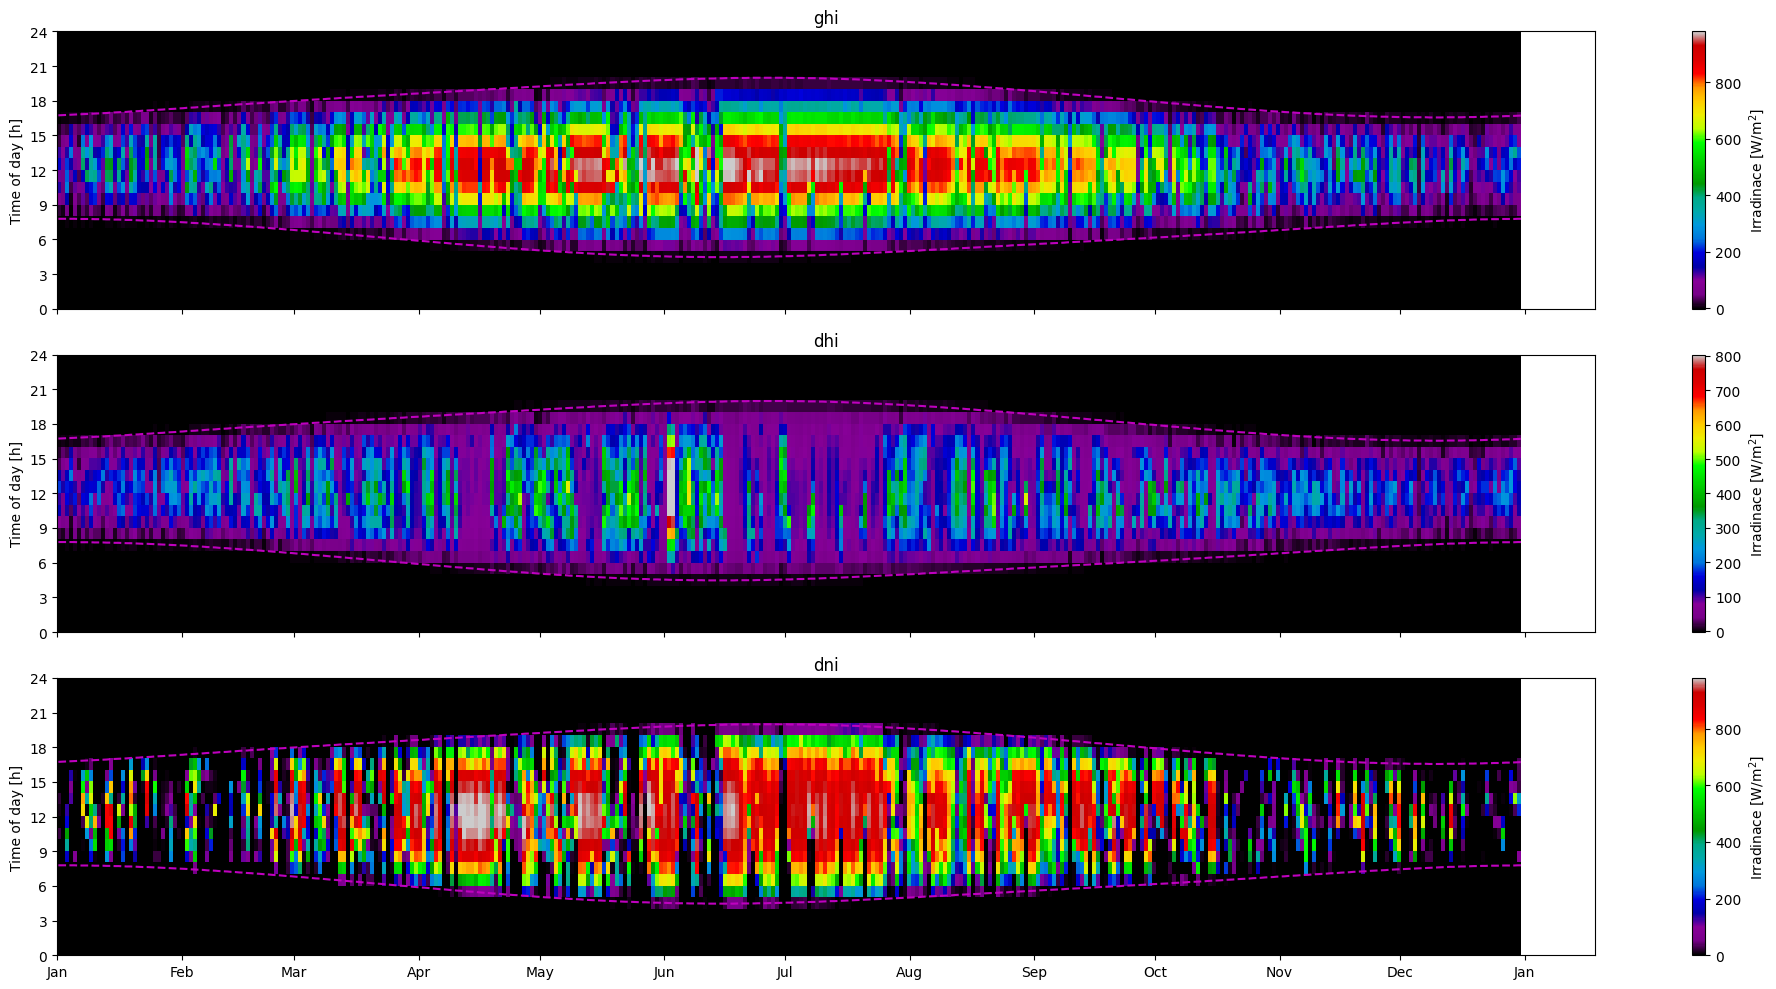

In [7]:
import matplotlib.dates as mdates
import datetime as dt
import numpy as np
# Creation of the 2D DataFrame, with time-of-day as rows and days as columns
df_2d = df.set_index([df.index.date, df.index.hour+df.index.minute/60]).unstack(level=0)

# Calculate the extents of the 2D plot, in the format [x_start, x_end, y_start, y_end]
xlims = mdates.date2num([df.index[0].date(), df.index[-1].date()])
extent = [xlims[0], xlims[1], 0, 24]

xticks = pd.date_range('2021-01-01', periods=13, freq='MS')

# Generate subplots and plot 2D DataFrame and sunrise/sunset line
fig, axes = plt.subplots(nrows=3, figsize=(20,10), sharex=True)
for i, c in enumerate(['ghi','dhi','dni']):
    im = axes[i].imshow(df_2d[c], aspect='auto', origin='lower', cmap='nipy_spectral',
                        extent=extent, vmax=df[c].quantile(0.999))
    axes[i].set_title(c)
    axes[i].xaxis_date()
    axes[i].set_yticks(np.arange(0,25,3))
    axes[i].set_ylabel('Time of day [h]')
    axes[i].plot(mdates.date2num(sunrise_sunset.index), sunrise_sunset[['sunrise', 'sunset']], 'm--')
    cbar = fig.colorbar(im, ax=axes[i], orientation='vertical', label='Irradinace [W/m$^2$]')

axes[-1].set_xticks(mdates.date2num(xticks))
axes[-1].set_xticklabels(xticks.strftime('%b'))

fig.tight_layout()

In [8]:
df['zenith'] = site.get_solarposition(df.index)['zenith']
df['extra_radiation'] = pvlib.irradiance.get_extra_radiation(df.index)
df['mu0'] = np.cos(np.deg2rad(df['zenith'])).clip(lower=0)

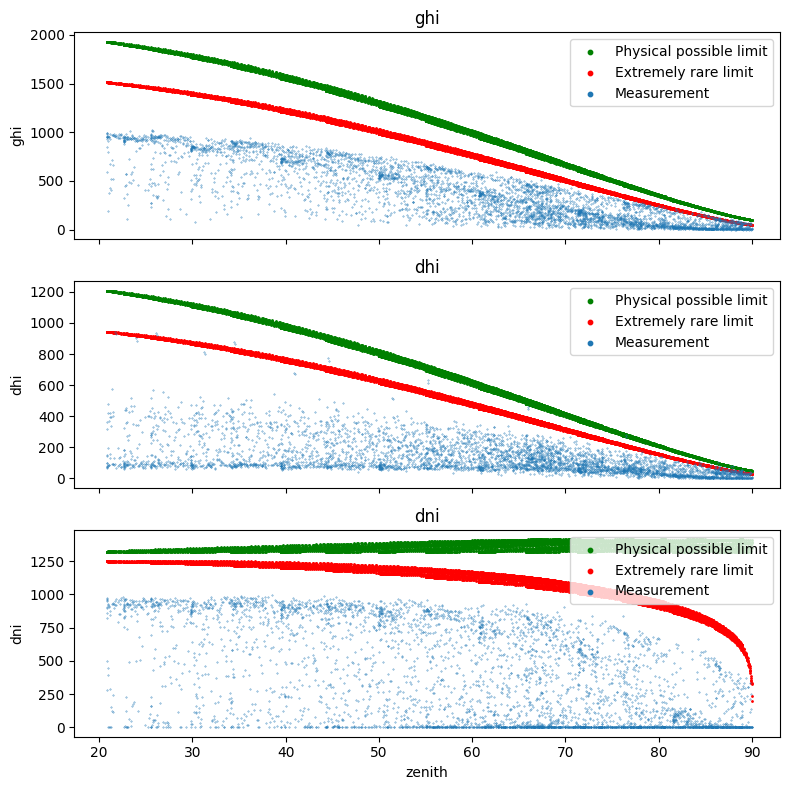

In [9]:
df_limits = pd.DataFrame(index=df.index, data={'zenith':df['zenith']})

# Physical possible limits
df_limits['ppl_upper_ghi'] = 1.5 * df['extra_radiation'] * df['mu0']**1.2 + 100
df_limits['ppl_upper_dhi'] = 0.95 * df['extra_radiation'] * df['mu0']**1.2 + 50
df_limits['ppl_upper_dni'] = 1 * df['extra_radiation']

# Extremely rare limits
df_limits['erl_upper_ghi'] = 1.2 * df['extra_radiation'] * df['mu0']**1.2 + 50
df_limits['erl_upper_dhi'] = 0.75 * df['extra_radiation'] * df['mu0']**1.2 + 30
df_limits['erl_upper_dni'] = 0.95 * df['extra_radiation'] * df['mu0']**0.2 + 10

# Plot measured data and limits
fig, axes = plt.subplots(nrows=3, figsize=(8,8), sharex=True)
for i, c in enumerate(['ghi','dhi','dni']):
    df_limits[df_limits['zenith']<90].plot.scatter(ax=axes[i], x='zenith', y='ppl_upper_{}'.format(c), s=1, c='g', label='Physical possible limit')
    df_limits[df_limits['zenith']<90].plot.scatter(ax=axes[i], x='zenith', y='erl_upper_{}'.format(c), s=1, c='r', label='Extremely rare limit')
    df[df_limits['zenith']<90].plot.scatter(ax=axes[i], x='zenith', y=c, s=0.1, alpha=0.9, xlim=[None,93], label='Measurement')
    axes[i].set_title(c)

    # Configure legend
    legend = axes[i].legend(loc='upper right')
    for handle in legend.legend_handles:
        handle.set_sizes([10])
        handle.set_alpha(1)

fig.tight_layout()
plt.show()

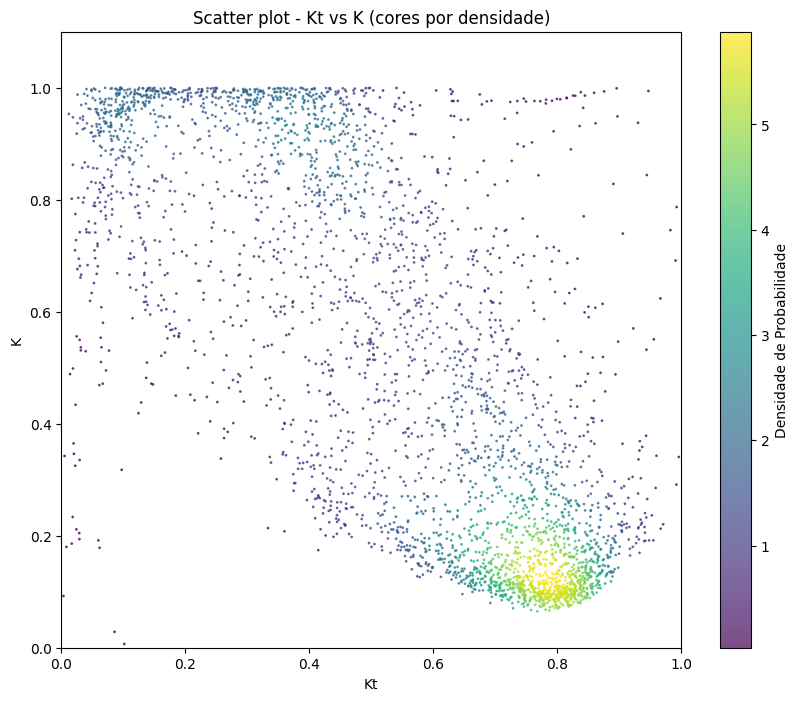

In [10]:
import numpy as np
from scipy.stats import gaussian_kde

df['K'] = df['dhi'] / df['ghi']
df['Kt'] = df['ghi'] / (df['extra_radiation'] * df['mu0'])

plt.figure(figsize=(10,8))

# Filtrar de forma mais rigorosa
df_filtered = df[
    (df['Kt'] < 1) & (df['K'] < 1) &  # Limites mais conservadores
    (df['Kt'] > 0) & (df['K'] > 0) &
    (df['Kt'].notna()) & (df['K'].notna()) &
    np.isfinite(df['Kt']) & np.isfinite(df['K'])
].copy()

'''# Remover outliers extremos (opcional)
Q1_Kt = df_filtered['Kt'].quantile(0.01)
Q3_Kt = df_filtered['Kt'].quantile(0.99)
Q1_K = df_filtered['K'].quantile(0.01)
Q3_K = df_filtered['K'].quantile(0.99)

df_filtered = df_filtered[
    (df_filtered['Kt'] >= Q1_Kt) & (df_filtered['Kt'] <= Q3_Kt) &
    (df_filtered['K'] >= Q1_K) & (df_filtered['K'] <= Q3_K)
]'''

if len(df_filtered) > 10:  # Precisa de pelo menos alguns pontos
    # Calcular a densidade
    xy = np.vstack([df_filtered['Kt'], df_filtered['K']])
    z = gaussian_kde(xy)(xy)

    # Plotar
    scatter = plt.scatter(df_filtered['Kt'], df_filtered['K'], c=z, s=1, cmap='viridis', alpha=0.7)
    plt.xlabel('Kt')
    plt.ylabel('K')
    plt.title('Scatter plot - Kt vs K (cores por densidade)')
    plt.xlim([0,1])
    plt.ylim([0,1.1])
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('Densidade de Probabilidade')
    
    plt.show()
else:
    print(f"Apenas {len(df_filtered)} pontos válidos encontrados")